# Q9 Decision Tree Sub-Model
**Question:** *How many different fashion styles might you spot within a 10-minute walk in the city?*

**Note:** Like Q8, the main modeling challenge here is data cleaning rather than
feature extraction. Unlike Q8, Q9 is stored as text in the
cleaned dataset, because a few responses like "1,000" contain a comma. This means. Q9 needs an extra numeric-conversion step before any of the Q8-style cleaning can be applied. Splits/thresholds are tuned with sklearn during exploration and the final fitted tree is implemented in numpy at
the end for pred.py.

In [1]:
import matplotlib.pyplot as plt # For plotting
import numpy as np              # Linear algebra library
import pandas as pd             # For manipulating tabular data
import re

Step 1: Create the master dataframe

In [2]:
# Load the raw master dataset (same file used for every sub-model)
df_master = pd.read_csv('cleaned_dataset.csv')

# Drop any rows missing labels and reset the index to establish absolute row positions
df_master = df_master.dropna(subset=['Label']).reset_index(drop=True)

df_master.describe()

,id,Q1,Q2,Q3,Q4,Q8
count,1462.000000,1462.000000,1461.000000,1461.000000,1462.000000,1461.000000
mean,460237.614911,4.321477,3.521561,3.707734,3.391929,4.796030
std,112789.365108,0.884464,1.192031,1.142037,1.297189,22.142305
min,5978.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,407927.000000,4.000000,3.000000,3.000000,2.000000,2.000000
50%,503416.000000,5.000000,4.000000,4.000000,3.000000,3.000000
75%,522169.000000,5.000000,5.000000,5.000000,5.000000,5.000000
max,727099.000000,5.000000,5.000000,5.000000,5.000000,800.000000


Step 2: Data split (identical code to all sub-models)

In [3]:
# Capture a master index array representing every single row position, and randomize rows
df_master = df_master.sample(frac=1, random_state=42).reset_index(drop=True)

master_indices = np.arange(len(df_master))
labels = df_master['Label']

# Print the first 20 rows of the shuffled dataset to verify randomization
print("=== SHUFFLE VERIFICATION REPORT ===")
print(df_master[['Label']].head(20))

print("\n=== CLASS DISTRIBUTION IN TOP 20 ROWS ===")
print(df_master['Label'].head(20).value_counts())

=== SHUFFLE VERIFICATION REPORT ===
             Label
0    New York City
1            Paris
2   Rio de Janeiro
3   Rio de Janeiro
4    New York City
5   Rio de Janeiro
6            Dubai
7            Paris
8   Rio de Janeiro
9    New York City
10  Rio de Janeiro
11           Paris
12   New York City
13  Rio de Janeiro
14           Paris
15           Paris
16           Dubai
17           Paris
18           Paris
19           Dubai

=== CLASS DISTRIBUTION IN TOP 20 ROWS ===
Label
Paris             7
Rio de Janeiro    6
New York City     4
Dubai             3
Name: count, dtype: int64


In [4]:
from sklearn.model_selection import train_test_split

# Step A: Isolate 20% of indices for the Final Evaluation/Test Set
train_meta_idx, global_test_idx, y_train_meta, y_test = train_test_split(
    master_indices, labels, test_size=0.20, stratify=labels, random_state=42
)

# Step B: Split the remaining 80% into 70% Training and 10% Validation indices
global_train_idx, global_val_idx, y_train, y_val = train_test_split(
    train_meta_idx, y_train_meta, test_size=0.125, stratify=y_train_meta, random_state=42
)

# Step C: Split the 70% Training into 80% sub-model training + 20% sub-model validation
labels_train_pool = labels[global_train_idx]
train_idx, val_idx, y_sub_train, y_sub_val = train_test_split(
    global_train_idx, labels_train_pool, test_size=0.20, stratify=labels_train_pool, random_state=42
)

print("=== GLOBAL INDEX SPLIT REGISTRY (identical to Q8/Q10) ===")
print(f"Training Row Indices (70%):  {len(global_train_idx)} rows")
print(f"Validation Row Indices (10%): {len(global_val_idx)} rows")
print(f"Evaluation Row Indices (20%): {len(global_test_idx)} rows")
print(f"Sub-model Training Row Indices (80% of 70%):  {len(train_idx)} rows")
print(f"Sub-model Validation Row Indices (20% of 70%): {len(val_idx)} rows")

=== GLOBAL INDEX SPLIT REGISTRY (identical to Q8/Q10) ===
Training Row Indices (70%):  1022 rows
Validation Row Indices (10%): 147 rows
Evaluation Row Indices (20%): 293 rows
Sub-model Training Row Indices (80% of 70%):  817 rows
Sub-model Validation Row Indices (20% of 70%): 205 rows


Step 3: Cleaning and preparing Q9 for modeling

Q9 is an integer response like Q8, but it's stored as a string in `cleaned_dataset.csv`, because a handful of responses (e.g. "1,000") contain a comma, which forces the whole column to be read as text rather than a number. We first strip commas and convert to numeric, then inspect the distribution, then decide how to handle outliers/missing values, fitting
any statistics using only the training-pool rows (`global_train_idx`) to avoid leaking information about the validation/test distribution into our preprocessing.

In [5]:
q9_numeric = df_master['Q9'].astype(str).str.replace(',', '', regex=False)
df_master['Q9'] = pd.to_numeric(q9_numeric, errors='coerce')

print("--- Raw (converted) Q9 summary (entire dataset) ---")
print(df_master['Q9'].describe())

print("\nMissing values in Q9:", df_master['Q9'].isna().sum())

print("\n--- Largest 15 raw Q9 values ---")
print(sorted(df_master['Q9'].dropna().unique())[-15:])

print("\n--- Per-city raw Q9 summary ---")
print(df_master.groupby('Label')['Q9'].describe()[['count', 'mean', 'std', 'min', '50%', 'max']])

--- Raw (converted) Q9 summary (entire dataset) ---
count    1461.000000
mean       10.031485
std        30.834873
min         0.000000
25%         3.000000
50%         5.000000
75%        10.000000
max      1000.000000
Name: Q9, dtype: float64

Missing values in Q9: 1

--- Largest 15 raw Q9 values ---
[np.float64(40.0), np.float64(46.0), np.float64(50.0), np.float64(60.0), np.float64(67.0), np.float64(69.0), np.float64(78.0), np.float64(80.0), np.float64(81.0), np.float64(90.0), np.float64(99.0), np.float64(100.0), np.float64(200.0), np.float64(300.0), np.float64(1000.0)]

--- Per-city raw Q9 summary ---
                count       mean        std  min  50%     max
Label                                                        
Dubai           367.0   7.114441  12.039007  0.0  5.0   100.0
New York City   365.0  12.882192  21.701138  1.0  8.0   300.0
Paris           364.0  14.359890  55.620216  1.0  6.0  1000.0
Rio de Janeiro  365.0   5.797260   7.640802  1.0  4.0   100.0


In [7]:
# Use the median of the sub-model TRAINING rows only, to avoid leaking
# validation/test information into the imputed value.
train_median_q9 = df_master.loc[train_idx, 'Q9'].median()
df_master['Q9'] = df_master['Q9'].fillna(train_median_q9)
print(f"Imputed missing Q9 value(s) with training median: {train_median_q9}")

# Decide an outlier cap using only the training pool
# We use the 97th percentile of the TRAINING rows as the cap threshold, rather
# than a round number, so the choice is grounded in the observed data.
cap_value = np.percentile(df_master.loc[train_idx, 'Q9'], 97)
print(f"Outlier cap (97th percentile of training Q9): {cap_value}")

# Apply the same cap to every row (train/val/test)
df_master['Q9_capped'] = df_master['Q9'].clip(upper=cap_value)

# People often round to 5/10/20/50/100 when guessing rather than counting exactly.
# We test below whether this rounding behavior itself differs by city.
df_master['Q9_round5'] = (df_master['Q9'] % 5 == 0).astype(int)

feature_names = ['Q9_capped', 'Q9_round5']
print(f"\nFinal Q9 feature set: {feature_names}")

Imputed missing Q9 value(s) with training median: 5.0
Outlier cap (97th percentile of training Q9): 40.0

Final Q9 feature set: ['Q9_capped', 'Q9_round5']


Note: Because a decision tree's splits only depend on the rank order of a feature's values, capping is really the only cleaning step that changes what the tree can learn from Q9 alone. A log-transform would not change anything, since it's a monotonic transform and preserves rank order. That's why we capped instead of log-transforming. The same reasoning applies here as it did for Q8.

Step 4: Q9 data exploration

In [8]:
train_analysis_df = df_master.loc[global_train_idx]
print(train_analysis_df['Label'].value_counts())

Label
New York City     256
Dubai             256
Paris             255
Rio de Janeiro    255
Name: count, dtype: int64


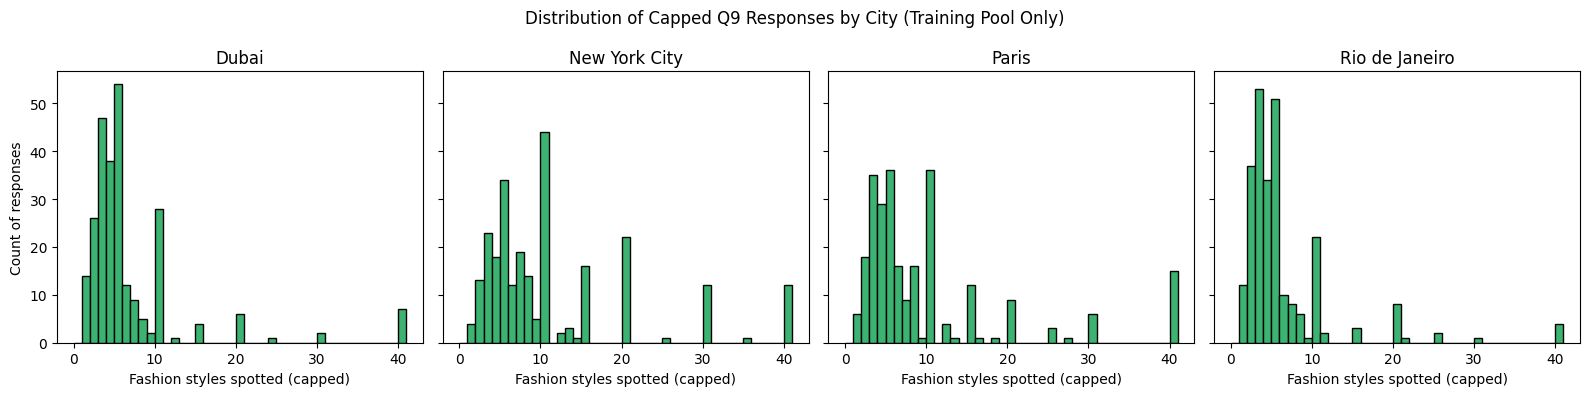

In [9]:
cities = train_analysis_df['Label'].unique()

fig, axes = plt.subplots(1, len(cities), figsize=(16, 4), sharey=True)
for ax, city in zip(axes, sorted(cities)):
    subset = train_analysis_df.loc[train_analysis_df['Label'] == city, 'Q9_capped']
    ax.hist(subset, bins=range(0, int(cap_value) + 2), color='mediumseagreen', edgecolor='black')
    ax.set_title(city)
    ax.set_xlabel('Fashion styles spotted (capped)')
axes[0].set_ylabel('Count of responses')
plt.suptitle('Distribution of Capped Q9 Responses by City (Training Pool Only)')
plt.tight_layout()
plt.show()

<Figure size 800x500 with 0 Axes>

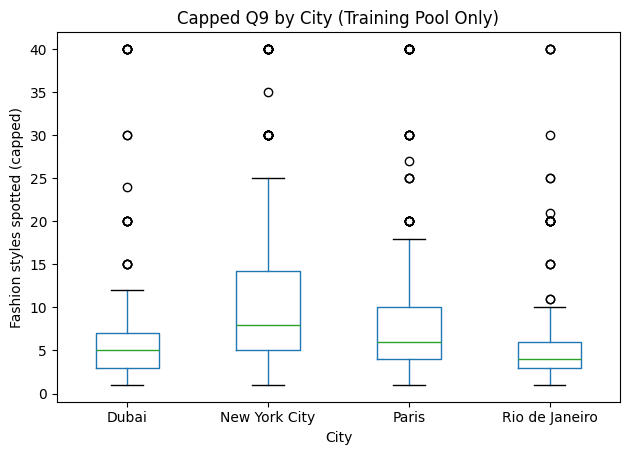

In [10]:
plt.figure(figsize=(8, 5))
train_analysis_df.boxplot(column='Q9_capped', by='Label', grid=False)
plt.title('Capped Q9 by City (Training Pool Only)')
plt.suptitle('')
plt.ylabel('Fashion styles spotted (capped)')
plt.xlabel('City')
plt.tight_layout()
plt.show()

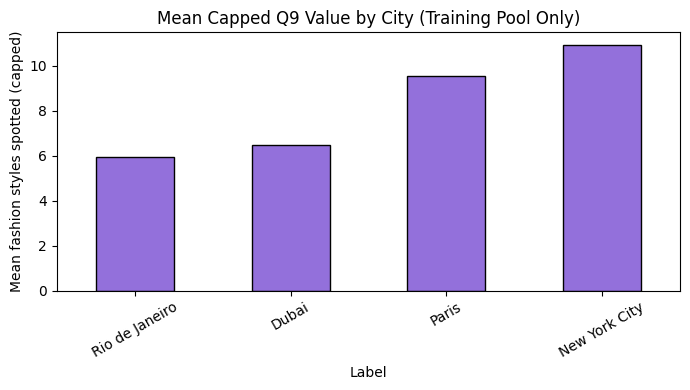

--- P(Q9 is a multiple of 5 | city) ---
Q9_round5              0         1
Label                             
Dubai           0.605469  0.394531
New York City   0.449219  0.550781
Paris           0.549020  0.450980
Rio de Janeiro  0.647059  0.352941


In [11]:
# Mean capped value per city
mean_by_city = train_analysis_df.groupby('Label')['Q9_capped'].mean().sort_values()
mean_by_city.plot(kind='bar', figsize=(7, 4), color='mediumpurple', edgecolor='black')
plt.title('Mean Capped Q9 Value by City (Training Pool Only)')
plt.ylabel('Mean fashion styles spotted (capped)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# Does "rounding behavior" differ by city?
print("--- P(Q9 is a multiple of 5 | city) ---")
print(pd.crosstab(train_analysis_df['Label'], train_analysis_df['Q9_round5'], normalize='index'))

Step 5: Data splitting for Q9

In [12]:
X = df_master[feature_names].to_numpy()
t = df_master['Label'].to_numpy()

X_train, t_train = X[train_idx], t[train_idx]
X_val,   t_val   = X[val_idx],   t[val_idx]

print(X_train.shape, X_val.shape)

(817, 2) (205, 2)


Step 6: Fit a DecisionTreeClassifier

Use entropy as the split criterion, fit on the sub-model training split, and report training/validation accuracy via .score().

In [13]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(criterion='entropy', max_depth=3)
tree.fit(X_train, t_train)

print('Training Accuracy:', tree.score(X_train, t_train))
print('Validation Accuracy:', tree.score(X_val, t_val))

Training Accuracy: 0.3659730722154223
Validation Accuracy: 0.28292682926829266


Visualize the tree

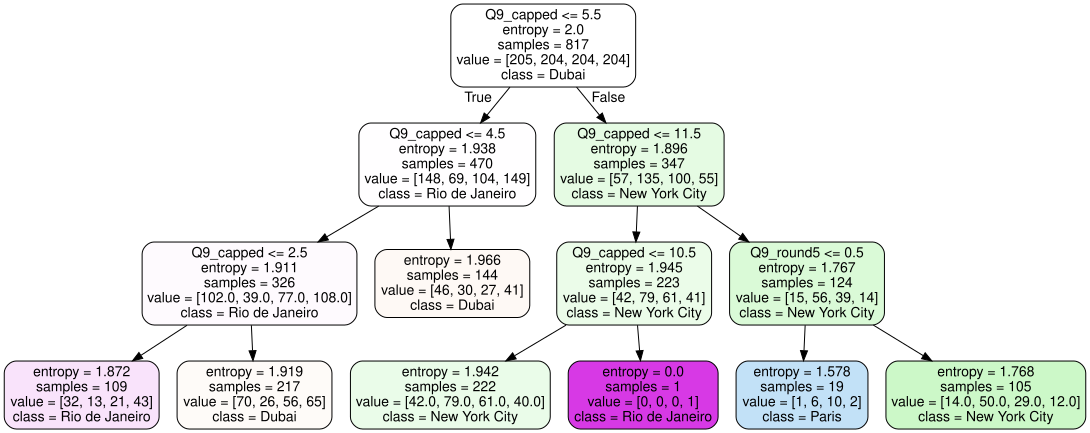

In [14]:
from sklearn import tree as treeViz
import graphviz
from IPython.display import display

def visualize_tree(model, max_depth=5):
    dot_data = treeViz.export_graphviz(
        model,
        feature_names=feature_names,
        max_depth=max_depth,
        class_names=model.classes_,
        filled=True,
        rounded=True,
    )
    return display(graphviz.Source(dot_data))

visualize_tree(tree)

In [17]:
example_idx = 19
print(dict(zip(feature_names, X_train[example_idx])))
print('True label:', t_train[example_idx])
print('Predicted label:', tree.predict(X_train[example_idx:example_idx+1])[0])

{'Q9_capped': np.float64(2.0), 'Q9_round5': np.float64(0.0)}
True label: Dubai
Predicted label: Rio de Janeiro


Note: Tried multiple different example indexes but none result in the correct prediction, just like Q8.

Step 7: Hyperparameter tuning via grid search

In [18]:
def build_all_models(max_depths, min_samples_splits, criterion,
                      X_train=X_train, t_train=t_train, X_valid=X_val, t_valid=t_val):
    """
    Builds one DecisionTreeClassifier per (max_depth, min_samples_split) combination and
    records training + validation accuracy for each, for a fixed split criterion.
    """
    out = {}
    for d in max_depths:
        for s in min_samples_splits:
            out[(d, s)] = {}
            tree = DecisionTreeClassifier(max_depth=d, min_samples_split=s, criterion=criterion)
            tree.fit(X_train, t_train)
            out[(d, s)]['val'] = tree.score(X_valid, t_valid)
            out[(d, s)]['train'] = tree.score(X_train, t_train)
    return out

In [20]:
criterions = ['entropy', 'gini']
# NOTE: with only 2 features (one of which is binary), depth beyond ~4-6 is very
# likely to just be memorizing training noise rather than learning real structure.
# This is an overfitting risk given how few features Q9 alone provides.
max_depths = [1, 2, 3, 4, 5, 6, 8, 10, 15, 20, None]
min_samples_splits = [2, 4, 8, 16, 32, 64, 128]

grid_results = {}
for criterion in criterions:
    print(f"\nUsing criterion {criterion}")
    res = build_all_models(max_depths, min_samples_splits, criterion)
    grid_results[criterion] = res

    best_val_score, best_params = -1, None
    for d, s in res:
        if res[(d, s)]['val'] > best_val_score:
            best_val_score, best_params = res[(d, s)]['val'], (d, s)

    print(f"Best parameters: max_depth={best_params[0]}, min_samples_split={best_params[1]}")
    print(f"Training accuracy: {res[best_params]['train']:.4f}")
    print(f"Validation accuracy: {res[best_params]['val']:.4f}")


Using criterion entropy
Best parameters: max_depth=6, min_samples_split=2
Training accuracy: 0.3758
Validation accuracy: 0.3415

Using criterion gini
Best parameters: max_depth=6, min_samples_split=2
Training accuracy: 0.3758
Validation accuracy: 0.3415


In [22]:
FINAL_CRITERION = 'entropy'         # <- set from grid search output above
FINAL_MAX_DEPTH = 6               # <- set from grid search output above
FINAL_MIN_SAMPLES_SPLIT = 2       # <- set from grid search output above

Step 8: Report training/validation accuracies for the final Q9 model

In [23]:
X_train = df_master.loc[train_idx, feature_names].to_numpy()
t_train = df_master.loc[train_idx, 'Label'].to_numpy()

final_tree = DecisionTreeClassifier(
    criterion=FINAL_CRITERION, max_depth=FINAL_MAX_DEPTH, min_samples_split=FINAL_MIN_SAMPLES_SPLIT
)
final_tree.fit(X_train, t_train)

train_acc = final_tree.score(X_train, t_train) * 100
val_acc   = final_tree.score(X_val, t_val) * 100

print("==================================================")
print(" Q9 DECISION TREE ACCURACY REPORT ")
print("==================================================")
print(f"Hyperparameters: criterion={FINAL_CRITERION} | max_depth={FINAL_MAX_DEPTH} | "
      f"min_samples_split={FINAL_MIN_SAMPLES_SPLIT}\n")
print(f"Training Accuracy (70% Pool):      {train_acc:.2f}%")
print(f"Validation Accuracy (Set B - 10%):  {val_acc:.2f}%")
print("==================================================")

 Q9 DECISION TREE ACCURACY REPORT 
Hyperparameters: criterion=entropy | max_depth=6 | min_samples_split=2

Training Accuracy (70% Pool):      37.58%
Validation Accuracy (Set B - 10%):  34.15%


Our optimized decision tree sub-model for Q8 achieved a final validation accuracy of 34.15%. This is a very weak validation accuracy.

In [24]:
t_ = final_tree.tree_
classes_ = final_tree.classes_

print("feature indices per node:", t_.feature[:10], "...")
print("thresholds per node:", t_.threshold[:10], "...")
print("classes:", classes_)

feature indices per node: [ 0  0  0  0 -2 -2  0 -2 -2 -2] ...
thresholds per node: [ 5.5  4.5  2.5  1.5 -2.  -2.   3.5 -2.  -2.  -2. ] ...
classes: ['Dubai' 'New York City' 'Paris' 'Rio de Janeiro']


In [25]:
def sklearn_free_predict(X, feature=t_.feature, threshold=t_.threshold,
                          children_left=t_.children_left, children_right=t_.children_right,
                          value=t_.value, classes=classes_):
    """
    Pure numpy/pandas re-implementation of sklearn's DecisionTreeClassifier.predict,
    using only the fitted tree's raw arrays. Safe to copy into pred.py.
    """
    preds = []
    for x in X:
        node = 0
        while children_left[node] != children_right[node]:  # not a leaf
            if x[feature[node]] <= threshold[node]:
                node = children_left[node]
            else:
                node = children_right[node]
        preds.append(classes[np.argmax(value[node])])
    return np.array(preds)

# Sanity check: this must match final_tree.predict(...) exactly
# sklearn_preds = final_tree.predict(X_val)
# manual_preds = sklearn_free_predict(X_val)
# print("Predictions match exactly:", np.array_equal(sklearn_preds, manual_preds))

Notes for pred.py:

1. Save `t_.feature`, `t_.threshold`, `t_.children_left`, `t_.children_right`, `t_.value`,
   and `classes_` to a small `.npz` file (np.savez), tiny for a shallow tree.
2. Also save `cap_value` and `train_median_q9` (both plain scalars), pred.py needs them to reproduce the exact same cleaning: first strip commas and convert Q9 to numeric, then impute with `train_median_q9`, then clip at `cap_value`, then compute `Q9_round5` the same way, before calling `sklearn_free_predict`. Recomputing these from the test CSV instead would leak test-set statistics into preprocessing and violate the fixed-pipeline assumption.
3. Copy `sklearn_free_predict` into `pred.py` unchanged; it only uses `numpy`.

Why only 2 features from Q9: a decision tree finds its own thresholds on a
continuous feature, so there's no benefit to hand-binning Q9_capped into buckets as the tree does that automatically as part of training.
Why cap instead of drop: dropping the outlier rows (e.g. the "1,000" response) would shrink an already-small per-city sample; capping keeps the row while preventing one implausible answer from creating a useless one-point leaf. Why Q9 needed an extra step Q8 didn't: Q9 contains a thousands-separator comma in at least one response ("1,000"), which forced pandas to read the whole column as text. Q8 never has this problem because none of its raw values are >= 1,000. With only 2 weak features derived from one noisy self-reported count, this submodel has a weak validation accuracy.